# Exoplanet Classification: Combined Kepler + TESS Dataset

## 1. Setup & Data Loading

All libraries are imported first: numpy and pandas for data manipulation, matplotlib and seaborn for plotting, and the relevant sklearn modules for preprocessing, modeling, and evaluation. Display settings are configured to show up to 60 columns and format floats to 4 decimal places. Both CSV files are then read from disk, and the shape and disposition counts for each are printed to confirm the load succeeded.

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer

sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

kepler = pd.read_csv('kepler_cumulative.csv')
tess   = pd.read_csv('tess_toi.csv')

print(f"Kepler : {kepler.shape[0]:,} rows × {kepler.shape[1]} columns")
print(f"  koi_disposition : {kepler['koi_disposition'].value_counts().to_dict()}\n")

print(f"TESS   : {tess.shape[0]:,} rows × {tess.shape[1]} columns")
print(f"  tfopwg_disp     : {tess['tfopwg_disp'].value_counts().to_dict()}")

Kepler : 9,564 rows × 153 columns
  koi_disposition : {'FALSE POSITIVE': 4839, 'CONFIRMED': 2747, 'CANDIDATE': 1978}

TESS   : 7,931 rows × 91 columns
  tfopwg_disp     : {'PC': 4780, 'FP': 1244, 'CP': 732, 'KP': 591, 'APC': 481, 'FA': 100}


Two datasets are loaded.

Kepler (9,564 rows) is NASA's Kepler Object of Interest cumulative catalog. Each row is one transit signal detected by the Kepler space telescope. The `koi_disposition` column classifies each signal:
- `CONFIRMED`: independently verified as a real planet
- `FALSE POSITIVE`: ruled out, usually an eclipsing binary or instrument artifact
- `CANDIDATE`: not yet vetted; dropped in preprocessing because there is no ground-truth label to train on

The TESS dataset uses `tfopwg_disp`, the TESS Follow-up Observing Program Working Group's disposition:
- `CP` (Confirmed Planet): verified planet
- `KP` (Known Planet): a previously known planet re-detected by TESS
- `PC` (Planet Candidate): not yet vetted; dropped for the same reason as Kepler `CANDIDATE`
- `FP` (False Positive): ruled out
- `EB` (Eclipsing Binary): a pair of stars whose mutual eclipses mimic a planetary transit; treated as a false positive

## 2. Preprocessing & Feature Selection

A feature list is defined upfront, omitting `koi_impact` since TESS has no equivalent column. Kepler rows labeled CANDIDATE are dropped, the remaining labels are encoded as 0/1, and a `source` column is tagged 'Kepler'. For TESS, only rows with a clear disposition (CP, KP, FP, EB) are kept; column names are remapped to Kepler's convention and labels are encoded the same way.

The two cleaned frames are concatenated and rows with any missing feature value are dropped. Two additional columns are then computed: `radius_ratio` divides planet radius by stellar radius in matched units, and `transit_duty_cycle` expresses transit duration as a fraction of the full orbital period. Rows where either calculation produced NaN or infinity are removed, and the final X, y, and source arrays are extracted.

In [2]:
SOLAR_RADIUS_IN_EARTH_RADII = 109.076

# koi_impact has no TESS equivalent, dropping it keeps the feature the same
# across both missions rather than filling half the rows with a constant 0
BASE_FEATURES = [
    'koi_period',    # orbital period (days)
    'koi_prad',      # planet radius (Earth radii)
    'koi_depth',     # transit depth (ppm)
    'koi_duration',  # transit duration (hours)
    'koi_steff',     # stellar effective temperature (K)
    'koi_srad',      # stellar radius (Solar radii)
    'koi_insol',     # insolation flux (Earth flux)
]

# --- Kepler ---
kepler_clean = kepler[kepler['koi_disposition'] != 'CANDIDATE'].copy()
kepler_clean['label']  = (kepler_clean['koi_disposition'] == 'CONFIRMED').astype(int)
kepler_clean['source'] = 'Kepler'
kepler_clean = kepler_clean[BASE_FEATURES + ['label', 'source']]

# --- TESS ---
# CP/KP = real planet, FP/EB = false positive; PC and APC are ambiguous, drop them
TESS_LABEL_MAP = {'CP': 1, 'KP': 1, 'FP': 0, 'EB': 0}
tess_labeled = tess[tess['tfopwg_disp'].isin(TESS_LABEL_MAP)].copy()
tess_labeled['label'] = tess_labeled['tfopwg_disp'].map(TESS_LABEL_MAP)

TESS_TO_KEPLER = {
    'pl_orbper'  : 'koi_period',
    'pl_rade'    : 'koi_prad',
    'pl_trandep' : 'koi_depth',
    'pl_trandurh': 'koi_duration',
    'st_teff'    : 'koi_steff',
    'st_rad'     : 'koi_srad',
    'pl_insol'   : 'koi_insol',
}

tess_clean = (tess_labeled[list(TESS_TO_KEPLER.keys()) + ['label']]
              .rename(columns=TESS_TO_KEPLER)
              .copy())
tess_clean['source'] = 'TESS'

# --- Combine ---
combined = (pd.concat([kepler_clean, tess_clean], ignore_index=True)
              .dropna(subset=BASE_FEATURES + ['label']))

# --- Feature engineering ---
combined['radius_ratio'] = (
    combined['koi_prad'] / (combined['koi_srad'] * SOLAR_RADIUS_IN_EARTH_RADII)
)
combined['transit_duty_cycle'] = (
    combined['koi_duration'] / (combined['koi_period'] * 24)
)

combined = combined[
    np.isfinite(combined['radius_ratio']) &
    np.isfinite(combined['transit_duty_cycle'])
].copy()

FEATURES = BASE_FEATURES + ['radius_ratio', 'transit_duty_cycle']

X      = combined[FEATURES].reset_index(drop=True)
y      = combined['label'].reset_index(drop=True)
source = combined['source'].reset_index(drop=True)

print(f"Combined shape : {combined.shape[0]:,} rows × {combined.shape[1]} columns")
print(f"X shape        : {X.shape}  ({len(BASE_FEATURES)} base + 2 engineered = {len(FEATURES)} features)")
print(f"y shape        : {y.shape}\n")

balance     = y.value_counts().rename({1: 'CONFIRMED (1)', 0: 'FALSE POSITIVE (0)'})
balance_pct = (balance / len(y) * 100).round(2)
print("-- Class balance --")
print(pd.DataFrame({'count': balance, 'pct %': balance_pct}).to_string())
print()

src_counts = source.value_counts()
print("-- Source breakdown --")
print(pd.DataFrame({'count': src_counts, 'pct %': (src_counts / len(source) * 100).round(2)}).to_string())

Combined shape : 9,725 rows × 11 columns
X shape        : (9725, 9)  (7 base + 2 engineered = 9 features)
y shape        : (9725,)

-- Class balance --
                    count   pct %
label                            
FALSE POSITIVE (0)   5684 58.4500
CONFIRMED (1)        4041 41.5500

-- Source breakdown --
        count   pct %
source               
Kepler   7327 75.3400
TESS     2398 24.6600


The combined shape counts rows remaining after merging both catalogs, dropping unlabeled candidates, and removing rows where the engineered features are NaN or infinite.

The class balance table uses numeric labels: 1 for a signal confirmed as a real planet, 0 for one ruled out. The dataset leans toward false positives (roughly 60/40), which reflects how common instrument artifacts and eclipsing binaries are relative to actual planets. `class_weight='balanced'` in the Random Forest corrects for this by up-weighting the minority class during training.

The source breakdown shows how many rows came from each mission. Kepler contributes the majority because it has a much larger vetted catalog. TESS adds diversity: it observes different sky regions and tends to find shorter-period planets around brighter stars.

## 3. Exploratory Data Analysis: Feature Distributions by Class

A subplot grid is set up with one panel per feature. Inside the loop, each feature's values are split by class label. If the feature belongs to the log-scale set, bins are computed with `np.logspace` and the x-axis is switched to log scale; otherwise linear bins are used. Both classes are plotted as overlapping, density-normalized histograms on the same axis. After the loop, any unused subplot slots are hidden, and a single shared legend is placed outside the right edge of the figure.

findfont: Failed to find font weight semibold, now using 700.


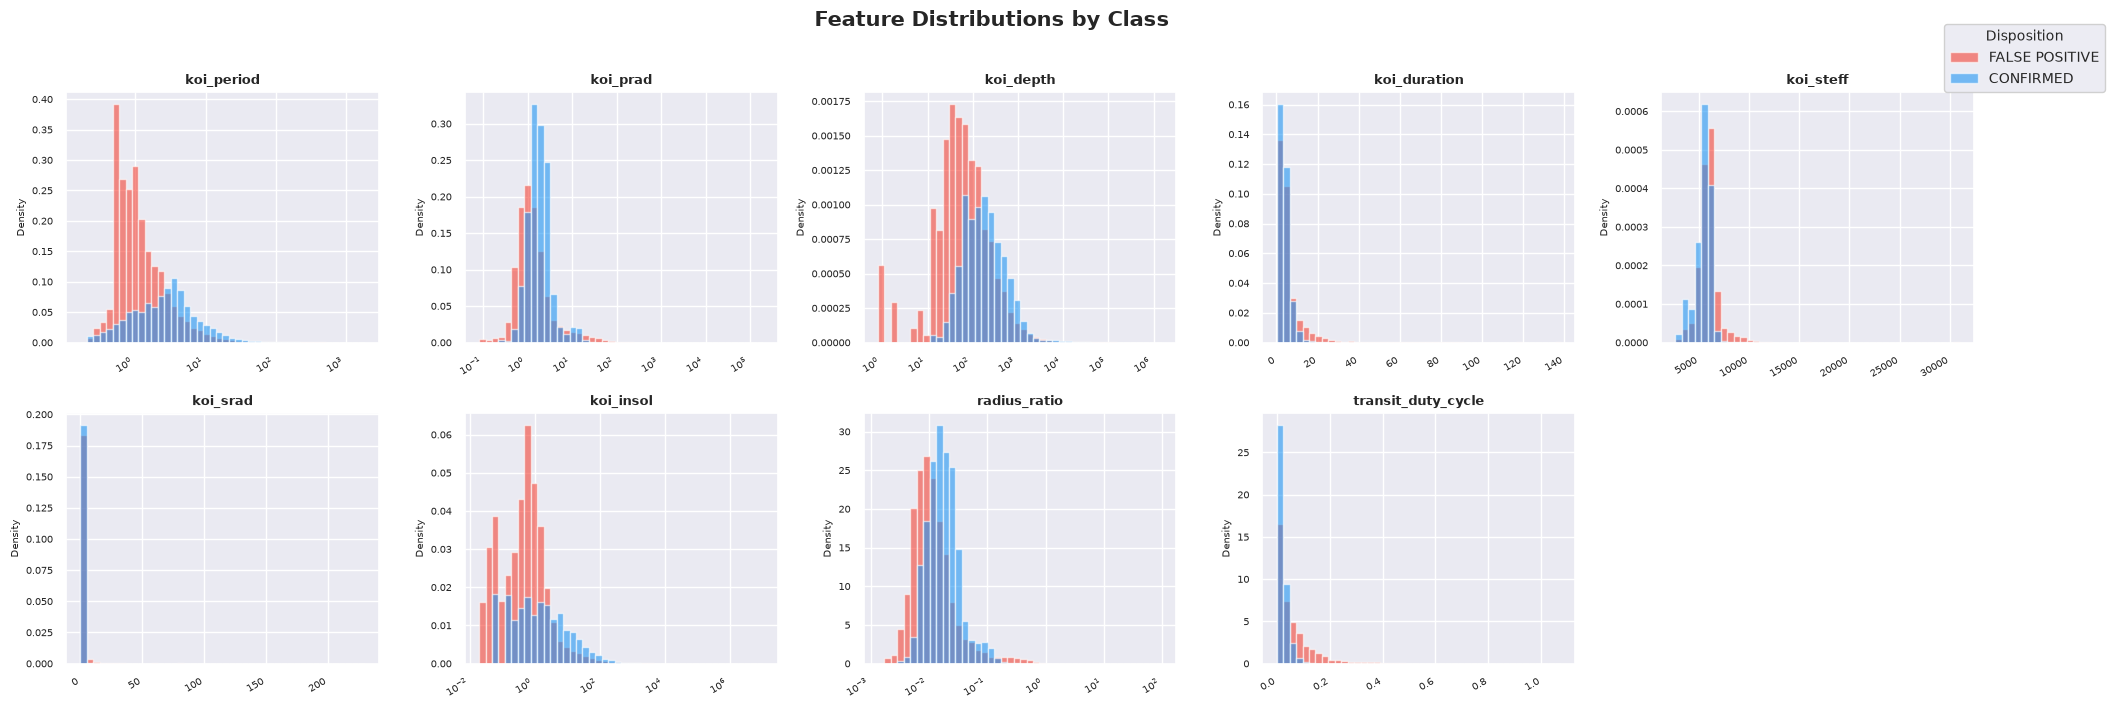

In [3]:
LOG_SCALE_FEATURES = {'koi_period', 'koi_prad', 'koi_depth', 'koi_insol', 'radius_ratio'}

CLASS_PALETTE = {1: '#2196F3', 0: '#F44336'}
CLASS_LABELS  = {1: 'CONFIRMED', 0: 'FALSE POSITIVE'}

n_features = len(FEATURES)
n_cols = 5
n_rows = -(-n_features // n_cols)   # round up

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3.5))
fig.suptitle('Feature Distributions by Class', fontsize=15, fontweight='bold', y=1.01)

for ax, feature in zip(axes.flat, FEATURES):
    confirmed = X.loc[y == 1, feature]
    fp        = X.loc[y == 0, feature]

    use_log  = feature in LOG_SCALE_FEATURES
    all_vals = pd.concat([confirmed, fp]).dropna()

    if use_log:
        pos  = all_vals[all_vals > 0]
        bins = np.logspace(np.log10(pos.min()), np.log10(pos.max()), 45)
    else:
        bins = np.linspace(all_vals.min(), all_vals.max(), 45)

    ax.hist(fp,        bins=bins, alpha=0.6, color=CLASS_PALETTE[0],
            label=CLASS_LABELS[0], density=True)
    ax.hist(confirmed, bins=bins, alpha=0.6, color=CLASS_PALETTE[1],
            label=CLASS_LABELS[1], density=True)

    if use_log:
        ax.set_xscale('log')

    ax.set_title(feature, fontsize=9, fontweight='semibold')
    ax.set_ylabel('Density', fontsize=7)
    ax.tick_params(labelsize=7)
    ax.xaxis.set_major_formatter(
        ticker.LogFormatterSciNotation() if use_log else ticker.ScalarFormatter()
    )
    plt.setp(ax.get_xticklabels(), rotation=30, ha='right')

# turn off the empty subplot slots
for ax in axes.flat[n_features:]:
    ax.set_visible(False)

handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1.06, 1.0),
           fontsize=10, framealpha=0.9, title='Disposition', title_fontsize=10)

fig.tight_layout()
plt.show()

Each subplot shows the density distribution of one feature. Blue bars are confirmed planets, red bars are false positives. Density on the y-axis (rather than raw counts) makes the two classes visually comparable despite the imbalance.

Some features use a log x-axis (`koi_period`, `koi_prad`, `koi_depth`, `koi_insol`, `radius_ratio`). These span several orders of magnitude, and a linear axis would compress most of the data into the left edge.

Features with little overlap between the two distributions are the ones the model leans on most heavily. Features where the classes nearly coincide add less discriminating power on their own.

`X.corr()` computes the full pairwise Pearson correlation matrix. A boolean upper-triangle mask is built with `np.triu` so each pair appears only once, then the masked matrix is passed to `sns.heatmap` with cell annotations and a coolwarm colormap centered at zero. On the right panel, `y.value_counts()` counts rows per class and a bar chart is drawn with count labels positioned just above each bar. The y-axis is formatted with comma separators using a `FuncFormatter`.

findfont: Failed to find font weight semibold, now using 700.


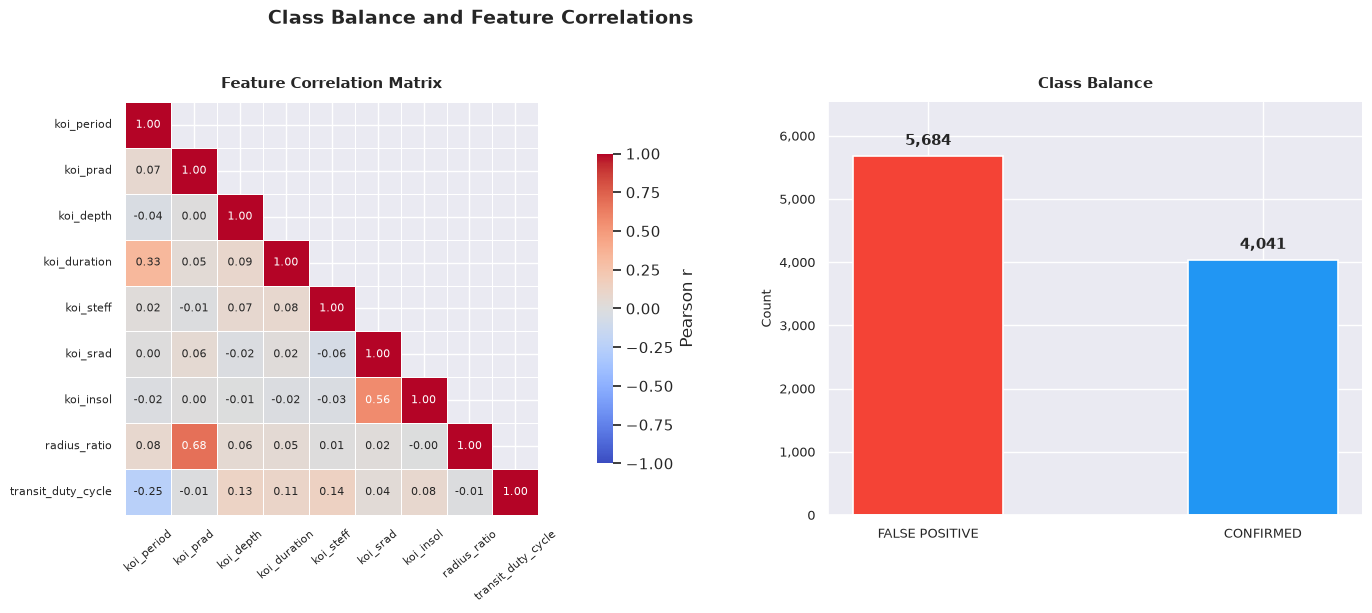

In [4]:
fig, (ax_corr, ax_bar) = plt.subplots(1, 2, figsize=(18, 6),
                                       gridspec_kw={'width_ratios': [2.2, 1]})
fig.suptitle('Class Balance and Feature Correlations', fontsize=14, fontweight='bold', y=1.02)

# left panel: how features relate to each other
corr = X.corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)   # only show the lower triangle

sns.heatmap(
    corr,
    ax=ax_corr,
    mask=mask,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 8},
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    linecolor='white',
    square=True,
    cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
)
ax_corr.set_title('Feature Correlation Matrix', fontsize=11, fontweight='semibold', pad=10)
ax_corr.tick_params(axis='x', rotation=40, labelsize=8)
ax_corr.tick_params(axis='y', rotation=0,  labelsize=8)

# right panel: how many of each class
counts = y.value_counts().sort_index()                 # false positives first, then confirmed
labels = ['FALSE POSITIVE', 'CONFIRMED']
colors = [CLASS_PALETTE[0], CLASS_PALETTE[1]]

bars = ax_bar.bar(labels, counts.values, color=colors, width=0.45, edgecolor='white', linewidth=1.2)

for bar, count in zip(bars, counts.values):
    ax_bar.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + counts.values.max() * 0.02,
        f'{count:,}',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

ax_bar.set_title('Class Balance', fontsize=11, fontweight='semibold', pad=10)
ax_bar.set_ylabel('Count', fontsize=9)
ax_bar.set_ylim(0, counts.values.max() * 1.15)
ax_bar.tick_params(labelsize=9)
ax_bar.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
sns.despine(ax=ax_bar)

fig.tight_layout()
plt.show()

The correlation matrix (left) shows the Pearson r between every pair of features. Values near +1 (dark red) mean the two features rise and fall together; near -1 (dark blue) they move in opposite directions; near 0 (white) there is no linear relationship. Only the lower triangle is shown since the matrix is symmetric. `radius_ratio` correlates strongly with `koi_prad` and `koi_srad` by construction, since it is computed directly from those two columns.

The bar chart (right) counts how many rows belong to each class in the cleaned dataset. More false positives than confirmed planets is the normal state in exoplanet surveys: most transit-like signals turn out not to be planets.

## 4. Model Training

`train_test_split` divides X, y, and source together in one call so the index alignment is guaranteed. `stratify=y` keeps the class ratio the same in both halves. A `Pipeline` is then built with two named steps: a `StandardScaler` followed by a `RandomForestClassifier`. When `pipeline.fit(X_train, y_train)` is called, the scaler computes its mean and variance from training data only, transforms the training set, and passes the result to the forest. Nothing from the test set touches the scaler's fit, which prevents data leakage.

In [5]:
X_train, X_test, y_train, y_test, src_train, src_test = train_test_split(
    X, y, source,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
                   n_estimators=200,
                   random_state=42,
                   class_weight='balanced',
               )),
])

pipeline.fit(X_train, y_train)

print(f"Training complete. Model fitted on {len(X_train):,} samples.")
print(f"  Train split : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.1f}%)")
print(f"  Test  split : {len(X_test):,}  rows  ({len(X_test)/len(X)*100:.1f}%)")

Training complete. Model fitted on 7,780 samples.
  Train split : 7,780 rows  (80.0%)
  Test  split : 1,945  rows  (20.0%)


The 80/20 split is stratified on `y`, so both halves preserve the same confirmed-to-false-positive ratio as the full dataset.

Two steps run in sequence inside the pipeline. StandardScaler centers each feature at zero and scales it to unit variance, so features measured in large units (stellar temperature in Kelvin) do not swamp features measured in small ones (radius ratio). RandomForestClassifier builds an ensemble of 200 decision trees, each trained on a random bootstrap sample and splitting on a random subset of features at each node. `class_weight='balanced'` up-weights confirmed-planet rows so the model does not default to predicting "false positive" on everything.

## 5. Model Evaluation

`pipeline.predict` generates hard class labels on the test set. `pipeline.predict_proba` returns a probability for each class, and column index 1 gives the probability of "confirmed planet". Both outputs feed into five metric functions, which are collected into a dict and printed.

Two plots follow. The confusion matrix is built with `confusion_matrix` and rendered as a seaborn heatmap with integer annotations. The ROC curve is constructed by calling `roc_curve` with the probability scores; it returns arrays of false positive rates and true positive rates at every possible threshold, which are then plotted as a line with the area beneath shaded.

-- Test-set metrics --
  Accuracy     0.8869
  Precision    0.8267
  Recall       0.9208
  F1-Score     0.8712
  ROC-AUC      0.9548



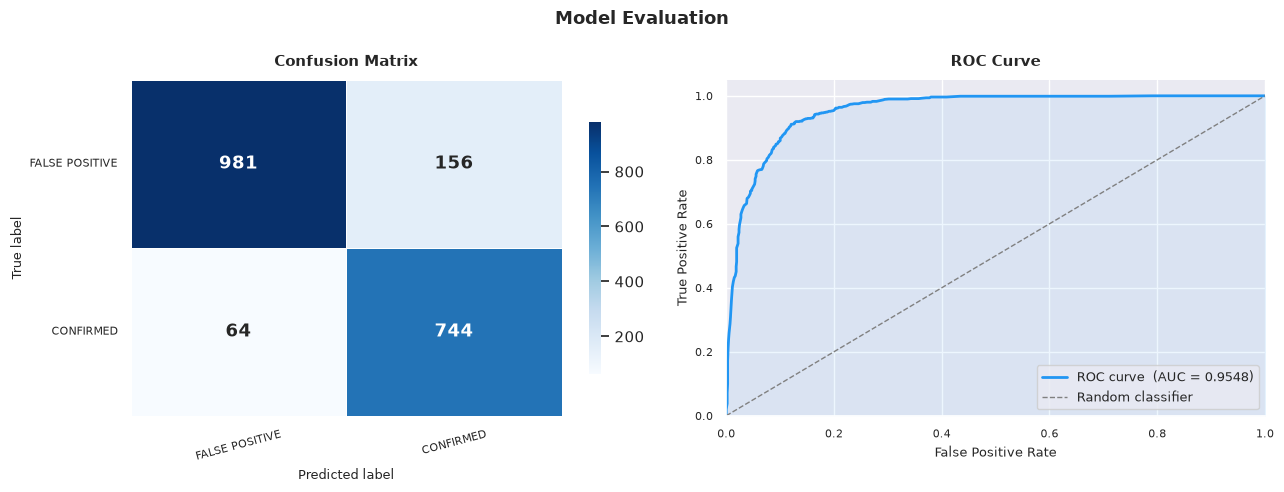

In [6]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix,
)

CLASS_NAMES = ['FALSE POSITIVE', 'CONFIRMED']   # 0 = false positive, 1 = confirmed

y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]  # probability of being a real planet

# crunch the numbers
metrics = {
    'Accuracy' : accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred),
    'Recall'   : recall_score(y_test, y_pred),
    'F1-Score' : f1_score(y_test, y_pred),
    'ROC-AUC'  : roc_auc_score(y_test, y_proba),
}

print("-- Test-set metrics --")
for name, val in metrics.items():
    print(f"  {name:<12} {val:.4f}")
print()

# now for the visual part
fig, (ax_cm, ax_roc) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Model Evaluation', fontsize=13, fontweight='bold')

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    ax=ax_cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    linewidths=0.5,
    linecolor='white',
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar_kws={'shrink': 0.75},
    annot_kws={'size': 13, 'fontweight': 'bold'},
)
ax_cm.set_title('Confusion Matrix', fontsize=11, fontweight='semibold', pad=10)
ax_cm.set_xlabel('Predicted label', fontsize=9)
ax_cm.set_ylabel('True label',      fontsize=9)
ax_cm.tick_params(axis='x', rotation=15, labelsize=8)
ax_cm.tick_params(axis='y', rotation=0,  labelsize=8)

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_val      = metrics['ROC-AUC']

ax_roc.plot(fpr, tpr, color='#2196F3', lw=2,
            label=f'ROC curve  (AUC = {auc_val:.4f})')
ax_roc.plot([0, 1], [0, 1], color='grey', lw=1, linestyle='--', label='Random classifier')
ax_roc.fill_between(fpr, tpr, alpha=0.08, color='#2196F3')

ax_roc.set_title('ROC Curve', fontsize=11, fontweight='semibold', pad=10)
ax_roc.set_xlabel('False Positive Rate', fontsize=9)
ax_roc.set_ylabel('True Positive Rate',  fontsize=9)
ax_roc.set_xlim([0.0, 1.0])
ax_roc.set_ylim([0.0, 1.05])
ax_roc.legend(loc='lower right', fontsize=9)
ax_roc.tick_params(labelsize=8)
sns.despine(ax=ax_roc)

fig.tight_layout()
plt.show()

The metrics table covers five numbers computed on the held-out test set.

| Metric | What it measures |
|---|---|
| Accuracy | Fraction of all predictions that are correct. Can mislead when classes are imbalanced. |
| Precision | Of all signals the model called "confirmed planet", what fraction actually are. High precision means few false alarms. |
| Recall | Of all actual confirmed planets, what fraction the model caught. High recall means few missed planets. |
| F1-Score | Harmonic mean of precision and recall. |
| ROC-AUC | Area under the ROC curve. 1.0 is perfect; 0.5 is random guessing. |

The confusion matrix (left) is a 2x2 grid where rows are the true label and columns are the predicted label. Top-left is true negatives (correctly rejected false positives), bottom-right is true positives (correctly confirmed planets). The off-diagonal cells are errors: bottom-left is a missed planet (false negative), top-right is a false alarm (false positive). Missed planets are typically the more costly error in this domain.

The ROC curve (right) sweeps the classification threshold from 0 to 1 and plots recall against the false positive rate at each step. The dashed diagonal is a random classifier. A curve closer to the top-left corner means the model catches most real planets while keeping false alarms low. The shaded area under the curve is the AUC score.

## 6. Feature Importance

`pipeline.named_steps['clf'].feature_importances_` retrieves the MDI scores that were accumulated during training. The values are wrapped in a pandas Series indexed by feature name, then sorted ascending so the highest-importance feature ends up at the top of the horizontal bar chart. Bar colors are mapped to importance values via `plt.Normalize` and the YlOrRd colormap. A separate `ScalarMappable` is constructed to attach a colorbar, since that object is not produced automatically by `ax.barh`. Value labels are placed just to the right of each bar with `ax.text`, and a caption is added below the figure with `fig.text`.

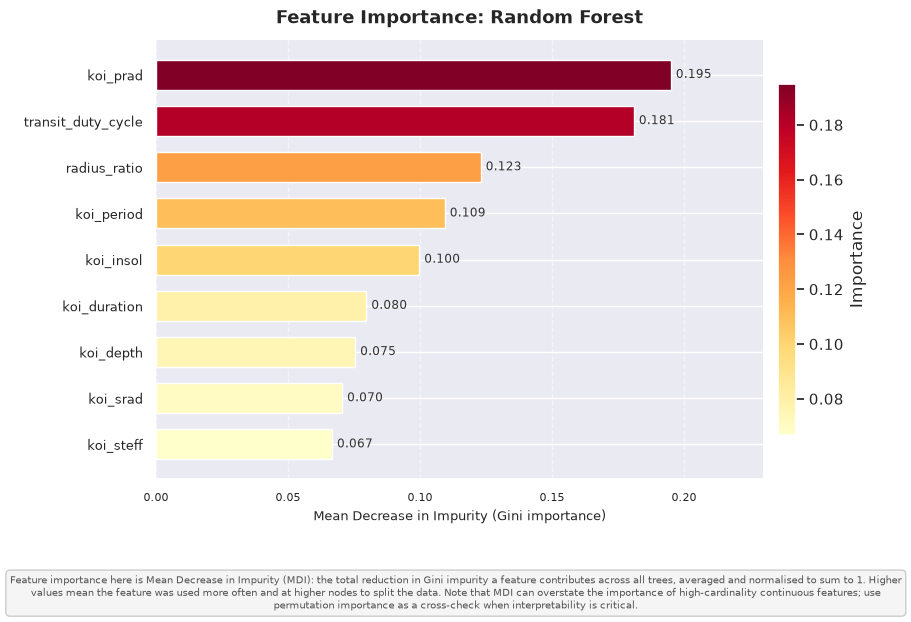

In [7]:
importances = pipeline.named_steps['clf'].feature_importances_
fi = (pd.Series(importances, index=FEATURES)
        .sort_values(ascending=True))   # lowest first so the most important ends up at the top

norm   = plt.Normalize(fi.min(), fi.max())
colors = plt.cm.YlOrRd(norm(fi.values))

fig, ax = plt.subplots(figsize=(9, 5.5))

bars = ax.barh(fi.index, fi.values, color=colors, edgecolor='white', height=0.65)

for bar, val in zip(bars, fi.values):
    ax.text(
        val + fi.max() * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center', ha='left', fontsize=8.5, color='#333333',
    )

sm = plt.cm.ScalarMappable(cmap='YlOrRd', norm=norm)
sm.set_array([])
fig.colorbar(sm, ax=ax, label='Importance', shrink=0.8, pad=0.02)

ax.set_title('Feature Importance: Random Forest', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Mean Decrease in Impurity (Gini importance)', fontsize=9)
ax.set_xlim(0, fi.max() * 1.18)
ax.tick_params(axis='y', labelsize=9)
ax.tick_params(axis='x', labelsize=8)
sns.despine(ax=ax, left=True)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)

caption = (
    "Feature importance here is Mean Decrease in Impurity (MDI): the total reduction in Gini "
    "impurity a feature contributes across all trees, averaged and normalised to sum to 1. "
    "Higher values mean the feature was used more often and at higher nodes to split the data. "
    "Note that MDI can overstate the importance of high-cardinality continuous features; "
    "use permutation importance as a cross-check when interpretability is critical."
)
fig.text(0.5, -0.06, caption, ha='center', va='top', fontsize=7.5,
         color='#555555', wrap=True,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#f5f5f5', edgecolor='#cccccc'))

fig.tight_layout()
plt.show()

Each bar is the Mean Decrease in Impurity (MDI) for that feature, also called Gini importance. After every split in every tree, the model records how much that split reduced disorder in the resulting child nodes. MDI averages those reductions across all 200 trees and normalizes so the values sum to 1. A longer bar means the feature drove more of the total information gain. The yellow-to-red color gradient reinforces the rank order, and exact values are printed at the end of each bar.

One caveat: MDI can overstate the importance of high-cardinality continuous features like `koi_period`, because more possible split points gives more chances to look useful on training data. Permutation importance is a less biased check when interpretability matters.

## 7. Per-Mission Performance Breakdown

Predictions and probabilities are recomputed on the test set. The code then iterates over the unique mission labels in `src_test`; for each one, a boolean mask selects only that mission's rows from the test arrays, and accuracy, F1, and ROC-AUC are computed on the subset. The per-mission results are collected into a list of dicts, converted to a DataFrame, and printed.

The same mask is applied a second time to build a per-mission confusion matrix. Each matrix is rendered as a seaborn heatmap in its own subplot, placed side by side in a single figure.

-- Per-mission metrics on test set --
            N  Confirmed   FP  Accuracy     F1  ROC-AUC
Mission                                                
Kepler   1449        549  900    0.9075 0.8845   0.9665
TESS      496        259  237    0.8266 0.8431   0.9076



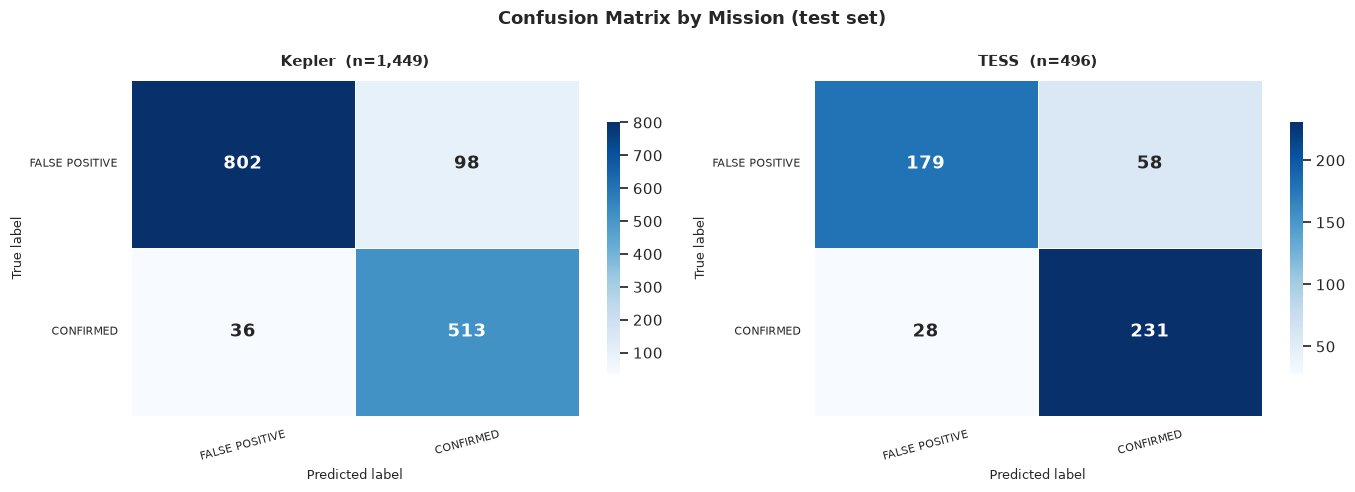

In [8]:
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

y_pred  = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

CLASS_NAMES = ['FALSE POSITIVE', 'CONFIRMED']

missions = src_test.unique()
rows = []
for mission in sorted(missions):
    mask = src_test.values == mission
    if mask.sum() == 0:
        continue
    yt, yp, ypr = y_test.values[mask], y_pred[mask], y_proba[mask]
    rows.append({
        'Mission'  : mission,
        'N'        : mask.sum(),
        'Confirmed': int(yt.sum()),
        'FP'       : int((yt == 0).sum()),
        'Accuracy' : accuracy_score(yt, yp),
        'F1'       : f1_score(yt, yp, zero_division=0),
        'ROC-AUC'  : roc_auc_score(yt, ypr) if len(np.unique(yt)) > 1 else float('nan'),
    })

perf = pd.DataFrame(rows).set_index('Mission')
print("-- Per-mission metrics on test set --")
print(perf.to_string())
print()

# side-by-side confusion matrices
fig, axes = plt.subplots(1, len(missions), figsize=(7 * len(missions), 5))
if len(missions) == 1:
    axes = [axes]
fig.suptitle('Confusion Matrix by Mission (test set)', fontsize=13, fontweight='bold')

for ax, mission in zip(axes, sorted(missions)):
    mask = src_test.values == mission
    cm   = confusion_matrix(y_test.values[mask], y_pred[mask])
    sns.heatmap(
        cm, ax=ax,
        annot=True, fmt='d', cmap='Blues',
        linewidths=0.5, linecolor='white',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cbar_kws={'shrink': 0.75},
        annot_kws={'size': 13, 'fontweight': 'bold'},
    )
    n = mask.sum()
    ax.set_title(f'{mission}  (n={n:,})', fontsize=11, fontweight='semibold', pad=10)
    ax.set_xlabel('Predicted label', fontsize=9)
    ax.set_ylabel('True label',      fontsize=9)
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

fig.tight_layout()
plt.show()

The metrics table breaks down model performance separately for the Kepler and TESS portions of the test set, using the same metrics as section 5.

| Column | Meaning |
|---|---|
| N | Total test rows from that mission |
| Confirmed | Rows labeled as confirmed planets |
| FP | Rows labeled as false positives |
| Accuracy | Fraction of correct predictions for that mission's rows |
| F1 | Harmonic mean of precision and recall |
| ROC-AUC | Area under the ROC curve; 1.0 is perfect, 0.5 is random |

The side-by-side confusion matrices show whether the model performs consistently across both telescopes. Lower recall for TESS would point to the model missing real TESS planets, likely because the training data is Kepler-heavy and the model has not fully absorbed TESS-specific transit patterns. Lower precision for TESS would mean TESS false positives look more planet-like in this feature space than Kepler ones do.

## 8. Additional Models: XGBoost, LightGBM & CatBoost

Three gradient-boosting frameworks are added alongside the Random Forest trained in section 4. All four models share the same 80/20 split and are wrapped in sklearn `Pipeline` objects with `StandardScaler`. Class imbalance is handled natively: XGBoost uses `scale_pos_weight` (the negative-to-positive count ratio), LightGBM uses `is_unbalance=True`, and CatBoost uses `auto_class_weights='Balanced'`. Training time for each model is measured so it can be compared against accuracy in section 9.

In [9]:
import time
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

MODELS = {
    'Random Forest': pipeline,
    'XGBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', XGBClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            scale_pos_weight=neg_pos_ratio,
            eval_metric='logloss',
            random_state=42,
            verbosity=0,
        )),
    ]),
    'LightGBM': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LGBMClassifier(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=6,
            is_unbalance=True,
            random_state=42,
            verbose=-1,
        )),
    ]),
    'CatBoost': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', CatBoostClassifier(
            iterations=200,
            learning_rate=0.1,
            depth=6,
            auto_class_weights='Balanced',
            random_seed=42,
            verbose=0,
        )),
    ]),
}

MODEL_COLORS = {
    'Random Forest': '#4CAF50',
    'XGBoost':       '#FF5722',
    'LightGBM':      '#2196F3',
    'CatBoost':      '#9C27B0',
}

FIT_TIMES = {}
for name, model in MODELS.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    FIT_TIMES[name] = time.time() - t0
    print(f"  {name:<15} fitted in {FIT_TIMES[name]:.2f}s")

print("\nAll 4 models ready.")

  Random Forest   fitted in 4.10s


  XGBoost         fitted in 30.02s


  LightGBM        fitted in 0.34s


  CatBoost        fitted in 0.76s

All 4 models ready.


## 9. Model Comparison

All four models are evaluated on the same held-out test set. First, predictions and probability scores are collected into shared dicts so every subsequent plot reads from a single source of truth. The comparison covers six angles: raw metric scores, ROC and precision-recall curves, confusion matrices, feature importances, 5-fold cross-validation stability, training speed, and per-mission breakdowns. The section closes with a heatmap and radar chart that put all dimensions side by side.

In [10]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    confusion_matrix,
)

PREDS   = {}
PROBAS  = {}
METRICS = []

for name, model in MODELS.items():
    yp  = model.predict(X_test)
    ypr = model.predict_proba(X_test)[:, 1]
    PREDS[name]  = yp
    PROBAS[name] = ypr
    METRICS.append({
        'Model'    : name,
        'Accuracy' : accuracy_score(y_test, yp),
        'Precision': precision_score(y_test, yp),
        'Recall'   : recall_score(y_test, yp),
        'F1'       : f1_score(y_test, yp),
        'ROC-AUC'  : roc_auc_score(y_test, ypr),
        'Avg Prec' : average_precision_score(y_test, ypr),
    })

results_df = pd.DataFrame(METRICS).set_index('Model')
print("Test-set metrics for all models:\n")
print(results_df.round(4).to_string())

Test-set metrics for all models:

               Accuracy  Precision  Recall     F1  ROC-AUC  Avg Prec
Model                                                               
Random Forest    0.8869     0.8267  0.9208 0.8712   0.9548    0.9244
XGBoost          0.8859     0.8178  0.9332 0.8717   0.9571    0.9272
LightGBM         0.8812     0.8167  0.9208 0.8656   0.9552    0.9209
CatBoost         0.8853     0.8197  0.9282 0.8706   0.9568    0.9275


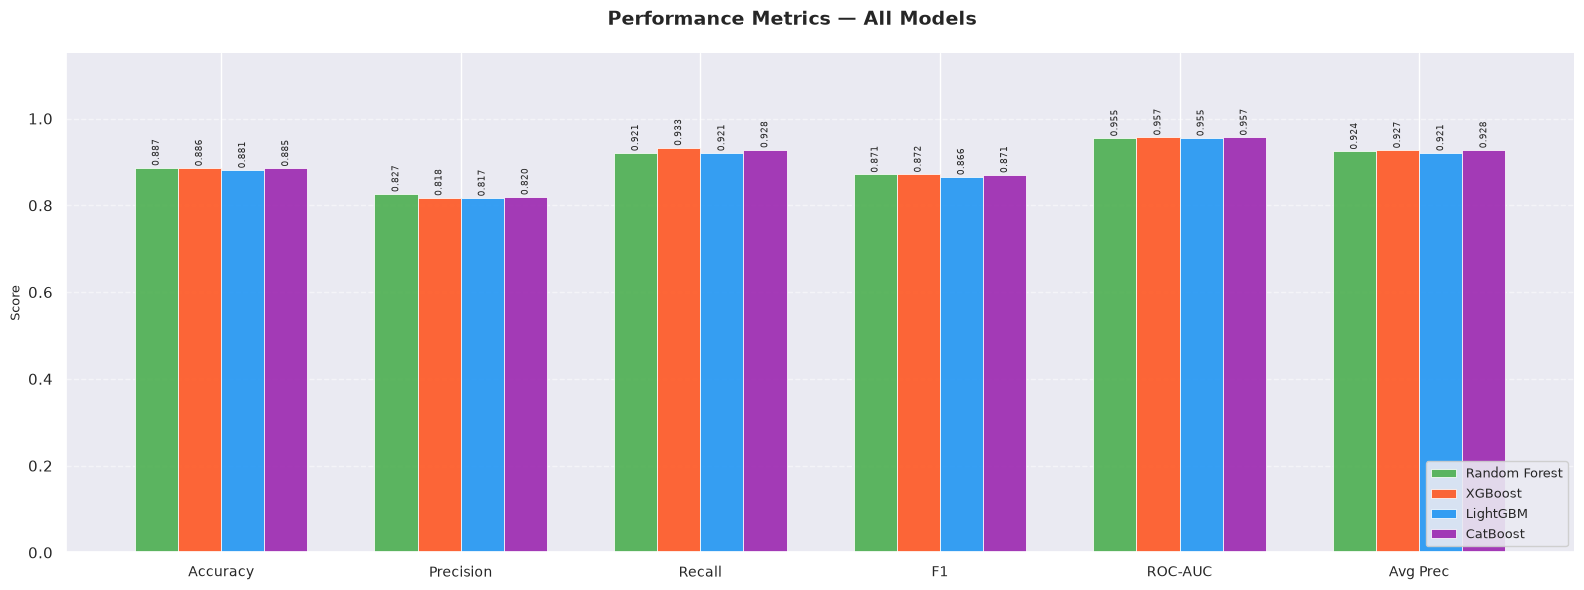

In [11]:
METRIC_COLS = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Avg Prec']
n_metrics   = len(METRIC_COLS)
n_mods      = len(MODELS)
x           = np.arange(n_metrics)
width       = 0.18

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Performance Metrics — All Models', fontsize=14, fontweight='bold')

for i, (name, row) in enumerate(results_df.iterrows()):
    offset = (i - n_mods / 2 + 0.5) * width
    vals   = [row[m] for m in METRIC_COLS]
    bars   = ax.bar(x + offset, vals, width=width, label=name,
                    color=MODEL_COLORS[name], edgecolor='white', linewidth=0.6, alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.004,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=6.5, rotation=90)

ax.set_xticks(x)
ax.set_xticklabels(METRIC_COLS, fontsize=10)
ax.set_ylabel('Score', fontsize=9)
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

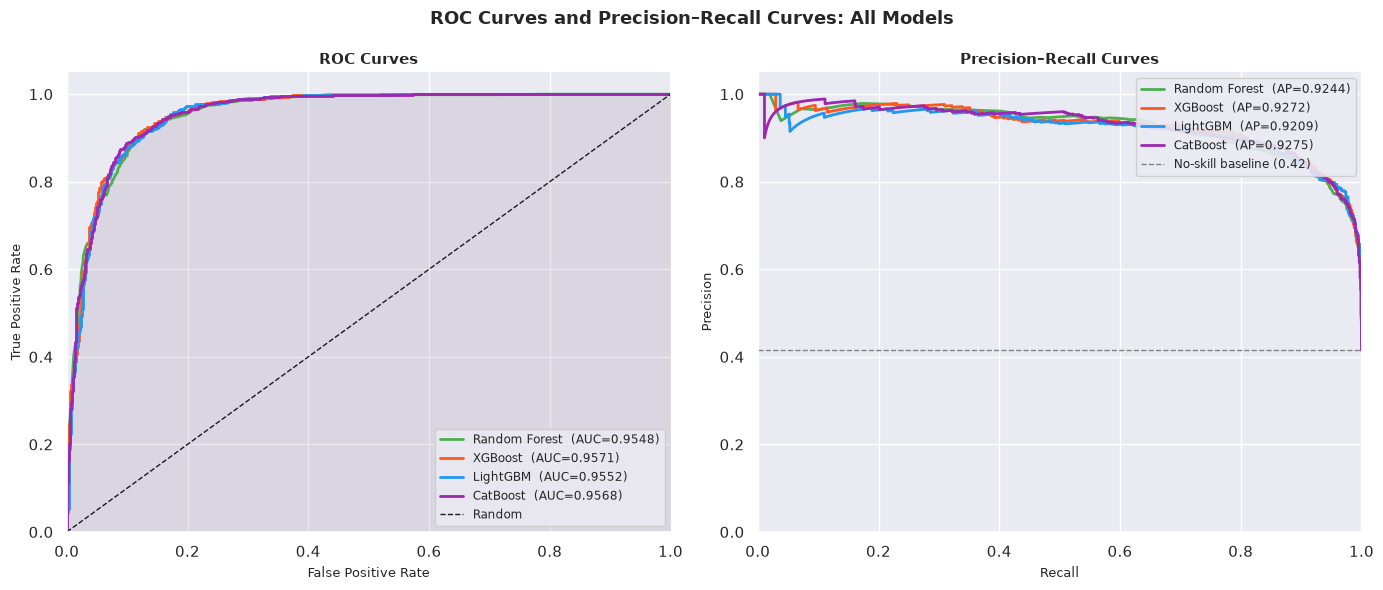

In [12]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('ROC Curves and Precision–Recall Curves: All Models', fontsize=13, fontweight='bold')

for name in MODELS:
    ypr   = PROBAS[name]
    color = MODEL_COLORS[name]
    auc   = results_df.loc[name, 'ROC-AUC']
    ap    = results_df.loc[name, 'Avg Prec']

    fpr, tpr, _ = roc_curve(y_test, ypr)
    ax_roc.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={auc:.4f})')
    ax_roc.fill_between(fpr, tpr, alpha=0.04, color=color)

    prec, rec, _ = precision_recall_curve(y_test, ypr)
    ax_pr.plot(rec, prec, color=color, lw=2, label=f'{name}  (AP={ap:.4f})')

ax_roc.plot([0, 1], [0, 1], 'k--', lw=1, label='Random')
ax_roc.set_xlabel('False Positive Rate', fontsize=9)
ax_roc.set_ylabel('True Positive Rate', fontsize=9)
ax_roc.set_title('ROC Curves', fontsize=11, fontweight='semibold')
ax_roc.legend(loc='lower right', fontsize=8.5, framealpha=0.9)
ax_roc.set_xlim(0, 1); ax_roc.set_ylim(0, 1.05)
sns.despine(ax=ax_roc)

baseline = y_test.mean()
ax_pr.axhline(baseline, color='grey', lw=1, linestyle='--',
              label=f'No-skill baseline ({baseline:.2f})')
ax_pr.set_xlabel('Recall', fontsize=9)
ax_pr.set_ylabel('Precision', fontsize=9)
ax_pr.set_title('Precision–Recall Curves', fontsize=11, fontweight='semibold')
ax_pr.legend(loc='upper right', fontsize=8.5, framealpha=0.9)
ax_pr.set_xlim(0, 1); ax_pr.set_ylim(0, 1.05)
sns.despine(ax=ax_pr)

fig.tight_layout()
plt.show()

findfont: Failed to find font weight semibold, now using 700.


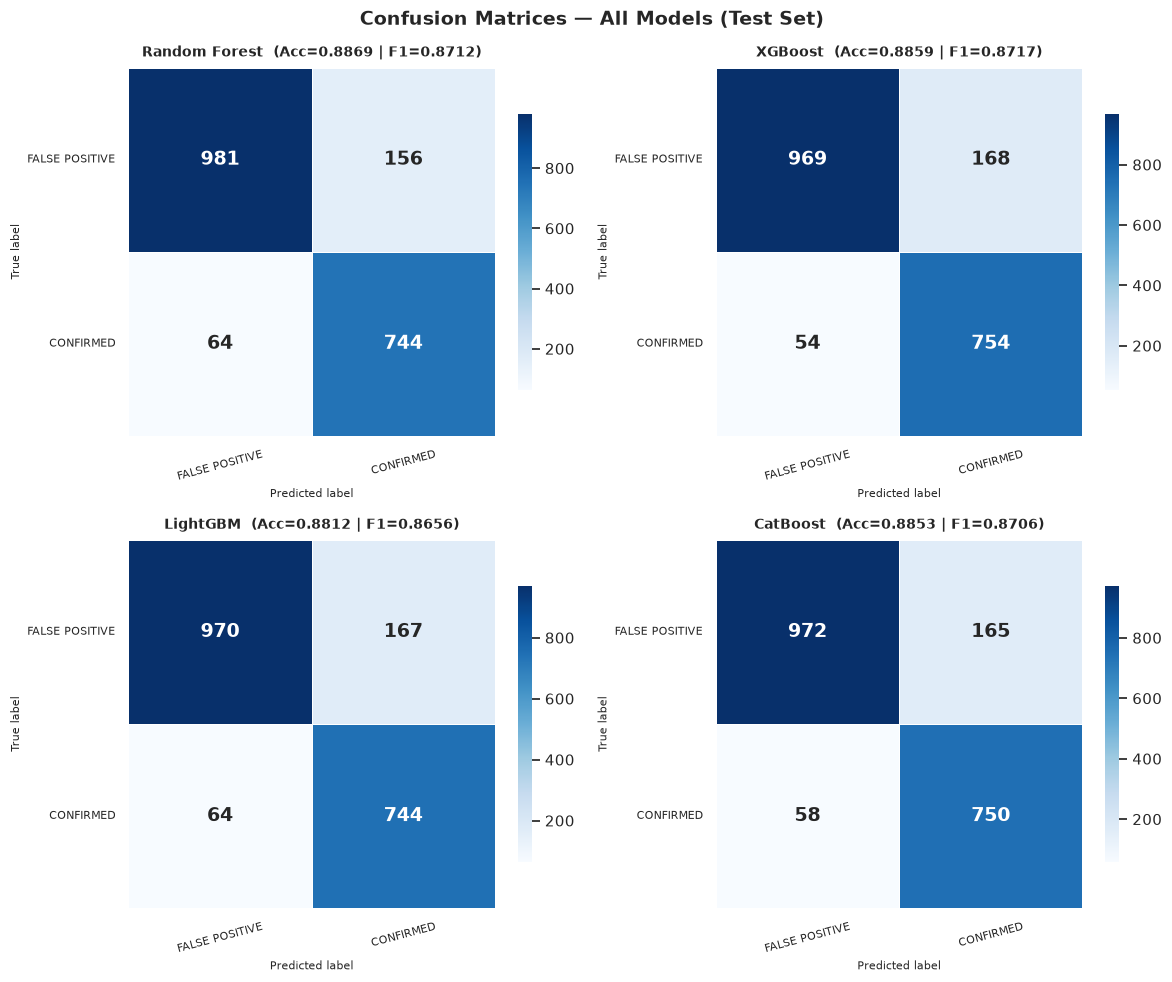

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Confusion Matrices — All Models (Test Set)', fontsize=14, fontweight='bold')

for ax, (name, yp) in zip(axes.flat, PREDS.items()):
    cm = confusion_matrix(y_test, yp)
    sns.heatmap(
        cm, ax=ax,
        annot=True, fmt='d', cmap='Blues',
        linewidths=0.5, linecolor='white',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        cbar_kws={'shrink': 0.75},
        annot_kws={'size': 14, 'fontweight': 'bold'},
    )
    acc = results_df.loc[name, 'Accuracy']
    f1v = results_df.loc[name, 'F1']
    ax.set_title(f'{name}  (Acc={acc:.4f} | F1={f1v:.4f})',
                 fontsize=10, fontweight='semibold', pad=8)
    ax.set_xlabel('Predicted label', fontsize=8)
    ax.set_ylabel('True label', fontsize=8)
    ax.tick_params(axis='x', rotation=15, labelsize=8)
    ax.tick_params(axis='y', rotation=0,  labelsize=8)

fig.tight_layout()
plt.show()

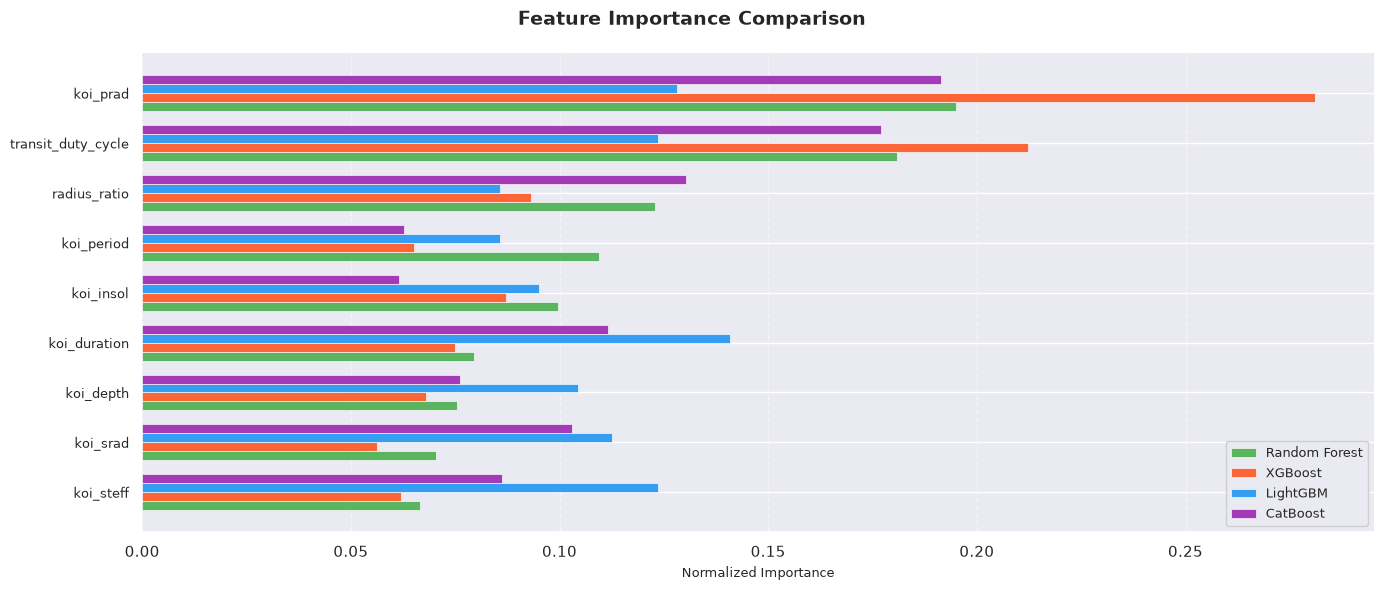

In [14]:
fi_data = {}
for name, model in MODELS.items():
    clf = model.named_steps['clf']
    if hasattr(clf, 'get_feature_importance'):   # CatBoost
        fi_data[name] = clf.get_feature_importance()
    else:
        fi_data[name] = clf.feature_importances_

fi_df = pd.DataFrame(fi_data, index=FEATURES)
fi_df = fi_df.div(fi_df.sum())          # normalize each column to sum to 1
fi_df = fi_df.sort_values('Random Forest', ascending=True)

n_feats = len(FEATURES)
n_mods  = len(MODELS)
x       = np.arange(n_feats)
width   = 0.18

fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Feature Importance Comparison', fontsize=14, fontweight='bold')

for i, col in enumerate(fi_df.columns):
    offset = (i - n_mods / 2 + 0.5) * width
    ax.barh(x + offset, fi_df[col].values, height=width,
            label=col, color=MODEL_COLORS[col], alpha=0.9,
            edgecolor='white', linewidth=0.5)

ax.set_yticks(x)
ax.set_yticklabels(fi_df.index, fontsize=9)
ax.set_xlabel('Normalized Importance', fontsize=9)
ax.legend(loc='lower right', fontsize=9, framealpha=0.9)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True)
fig.tight_layout()
plt.show()

  Random Forest    5-fold CV F1: 0.8669 ± 0.0109


  XGBoost          5-fold CV F1: 0.8676 ± 0.0078


  LightGBM         5-fold CV F1: 0.8691 ± 0.0080


  CatBoost         5-fold CV F1: 0.8691 ± 0.0100


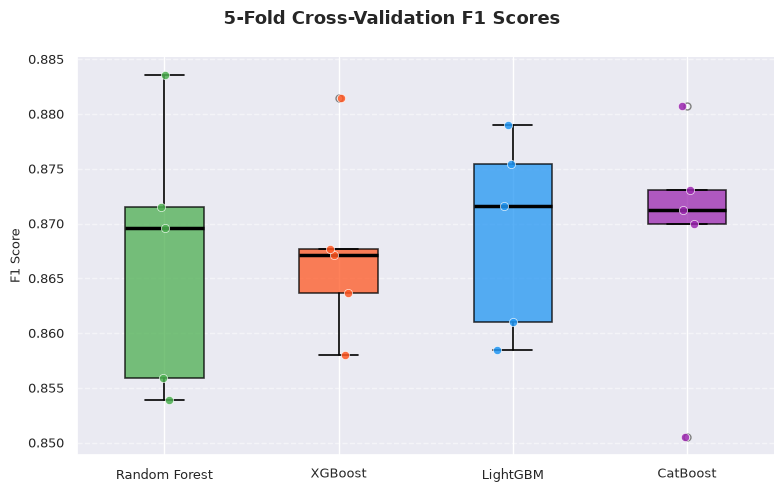

In [15]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
CV_SCORES = {}

for name, model in MODELS.items():
    scores = cross_val_score(model, X, y, cv=skf, scoring='f1', n_jobs=-1)
    CV_SCORES[name] = scores
    print(f"  {name:<15}  5-fold CV F1: {scores.mean():.4f} ± {scores.std():.4f}")

fig, ax = plt.subplots(figsize=(8, 5))
fig.suptitle('5-Fold Cross-Validation F1 Scores', fontsize=13, fontweight='bold')

bp = ax.boxplot(
    [CV_SCORES[n] for n in MODELS],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2.5),
    boxprops=dict(linewidth=1.2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='o', markersize=5, markeredgecolor='grey'),
)
ax.set_xticks(range(1, len(MODELS) + 1))
ax.set_xticklabels(list(MODELS.keys()), fontsize=9)

for patch, name in zip(bp['boxes'], MODELS):
    patch.set_facecolor(MODEL_COLORS[name])
    patch.set_alpha(0.75)

rng = np.random.default_rng(0)
for i, name in enumerate(MODELS, start=1):
    jitter = rng.normal(0, 0.04, size=len(CV_SCORES[name]))
    ax.scatter(i + jitter, CV_SCORES[name], color=MODEL_COLORS[name],
               alpha=0.85, s=35, zorder=3, edgecolors='white', linewidths=0.5)

ax.set_ylabel('F1 Score', fontsize=9)
ax.tick_params(labelsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine(ax=ax)
fig.tight_layout()
plt.show()

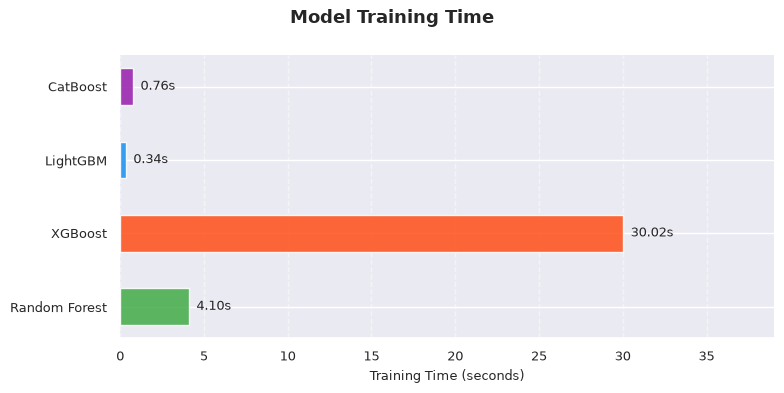

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
fig.suptitle('Model Training Time', fontsize=13, fontweight='bold')

names  = list(FIT_TIMES.keys())
times  = [FIT_TIMES[n] for n in names]
colors = [MODEL_COLORS[n] for n in names]

bars = ax.barh(names, times, color=colors, edgecolor='white', height=0.5, alpha=0.9)
for bar, t in zip(bars, times):
    ax.text(bar.get_width() + max(times) * 0.015,
            bar.get_y() + bar.get_height() / 2,
            f'{t:.2f}s', va='center', ha='left', fontsize=9)

ax.set_xlabel('Training Time (seconds)', fontsize=9)
ax.set_xlim(0, max(times) * 1.3)
ax.tick_params(labelsize=9)
ax.xaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
sns.despine(ax=ax, left=True)
fig.tight_layout()
plt.show()

Per-mission metrics for all models:

        Model Mission    N  Precision  Recall     F1  ROC-AUC
Random Forest  Kepler 1449     0.8396  0.9344 0.8845   0.9665
Random Forest    TESS  496     0.7993  0.8919 0.8431   0.9076
      XGBoost  Kepler 1449     0.8363  0.9490 0.8891   0.9705
      XGBoost    TESS  496     0.7793  0.8996 0.8351   0.9031
     LightGBM  Kepler 1449     0.8371  0.9454 0.8879   0.9687
     LightGBM    TESS  496     0.7732  0.8687 0.8182   0.9000
     CatBoost  Kepler 1449     0.8328  0.9435 0.8847   0.9690
     CatBoost    TESS  496     0.7918  0.8958 0.8406   0.9058


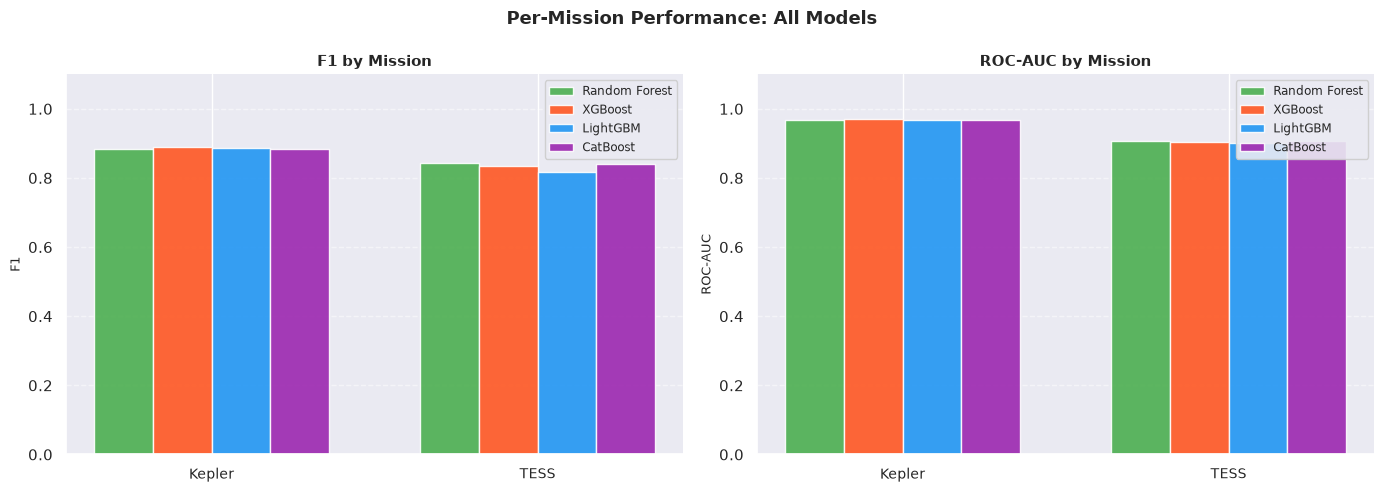

In [17]:
mission_rows = []
for name, model in MODELS.items():
    yp  = PREDS[name]
    ypr = PROBAS[name]
    for mission in sorted(src_test.unique()):
        mask = src_test.values == mission
        yt_m, yp_m, ypr_m = y_test.values[mask], yp[mask], ypr[mask]
        mission_rows.append({
            'Model'    : name,
            'Mission'  : mission,
            'N'        : int(mask.sum()),
            'Precision': precision_score(yt_m, yp_m, zero_division=0),
            'Recall'   : recall_score(yt_m, yp_m, zero_division=0),
            'F1'       : f1_score(yt_m, yp_m, zero_division=0),
            'ROC-AUC'  : roc_auc_score(yt_m, ypr_m) if len(np.unique(yt_m)) > 1 else np.nan,
        })

mission_df = pd.DataFrame(mission_rows)
print("Per-mission metrics for all models:\n")
print(mission_df.to_string(index=False))

missions_list = sorted(src_test.unique())
model_names   = list(MODELS.keys())
x             = np.arange(len(missions_list))
width         = 0.18

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Per-Mission Performance: All Models', fontsize=13, fontweight='bold')

for ax, metric in zip(axes, ['F1', 'ROC-AUC']):
    for i, name in enumerate(model_names):
        sub    = mission_df[mission_df['Model'] == name].set_index('Mission')
        offset = (i - len(model_names) / 2 + 0.5) * width
        vals   = [sub.loc[m, metric] for m in missions_list]
        ax.bar(x + offset, vals, width=width, label=name,
               color=MODEL_COLORS[name], alpha=0.9, edgecolor='white')
    ax.set_xticks(x)
    ax.set_xticklabels(missions_list, fontsize=10)
    ax.set_ylabel(metric, fontsize=9)
    ax.set_title(f'{metric} by Mission', fontsize=11, fontweight='semibold')
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=8.5, framealpha=0.9)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5)
    ax.set_axisbelow(True)
    sns.despine(ax=ax)

fig.tight_layout()
plt.show()

FINAL MODEL COMPARISON SUMMARY  (sorted by test F1 score)
               Accuracy  Precision  Recall     F1  ROC-AUC  Avg Prec  CV F1 Mean  CV F1 Std  Train Time (s)
Model                                                                                                      
XGBoost          0.8859     0.8178  0.9332 0.8717   0.9571    0.9272      0.8676     0.0078         30.0216
Random Forest    0.8869     0.8267  0.9208 0.8712   0.9548    0.9244      0.8669     0.0109          4.0995
CatBoost         0.8853     0.8197  0.9282 0.8706   0.9568    0.9275      0.8691     0.0100          0.7622
LightGBM         0.8812     0.8167  0.9208 0.8656   0.9552    0.9209      0.8691     0.0080          0.3360

Best by F1:        XGBoost
Best by ROC-AUC:   XGBoost
Fastest to train:  LightGBM


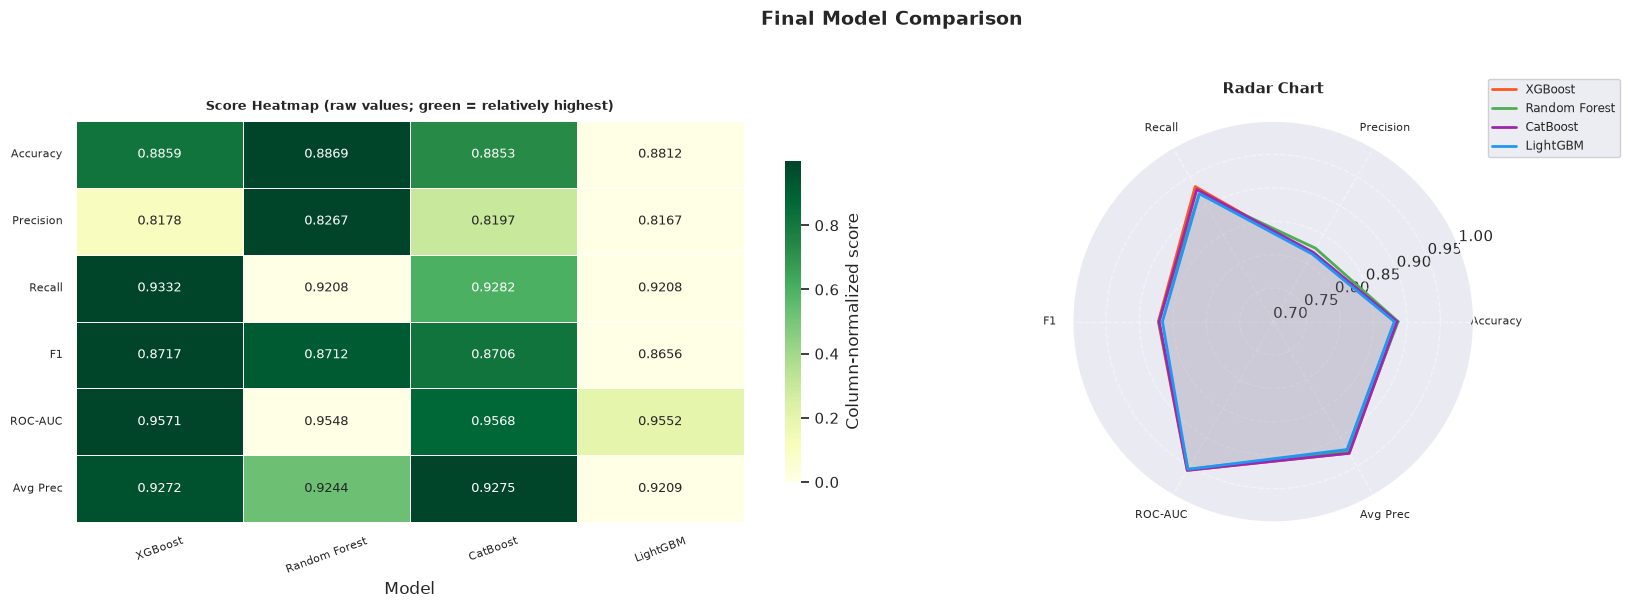

In [18]:
# --- Summary table ---
summary = results_df[['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Avg Prec']].copy()
summary['CV F1 Mean']     = [CV_SCORES[n].mean() for n in summary.index]
summary['CV F1 Std']      = [CV_SCORES[n].std()  for n in summary.index]
summary['Train Time (s)'] = [FIT_TIMES[n]         for n in summary.index]
summary = summary.sort_values('F1', ascending=False)

print("=" * 72)
print("FINAL MODEL COMPARISON SUMMARY  (sorted by test F1 score)")
print("=" * 72)
print(summary.round(4).to_string())
print()
print(f"Best by F1:        {summary['F1'].idxmax()}")
print(f"Best by ROC-AUC:   {summary['ROC-AUC'].idxmax()}")
print(f"Fastest to train:  {pd.Series(FIT_TIMES).idxmin()}")

# --- Heatmap + Radar ---
vis_metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC', 'Avg Prec']
hm_raw  = summary[vis_metrics]
hm_norm = (hm_raw - hm_raw.min()) / (hm_raw.max() - hm_raw.min() + 1e-9)

fig = plt.figure(figsize=(18, 6))
fig.suptitle('Final Model Comparison', fontsize=14, fontweight='bold', y=1.01)

# Heatmap (left)
ax_hm = fig.add_subplot(1, 2, 1)
sns.heatmap(
    hm_norm.T,
    ax=ax_hm,
    annot=hm_raw.T.round(4),
    fmt='.4f',
    cmap='YlGn',
    linewidths=0.5, linecolor='white',
    cbar_kws={'label': 'Column-normalized score', 'shrink': 0.8},
    annot_kws={'size': 9},
)
ax_hm.set_title('Score Heatmap (raw values; green = relatively highest)',
                fontsize=9, fontweight='semibold', pad=8)
ax_hm.tick_params(axis='x', rotation=20, labelsize=8)
ax_hm.tick_params(axis='y', rotation=0,  labelsize=8)

# Radar chart (right)
N      = len(vis_metrics)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]

ax_radar = fig.add_subplot(1, 2, 2, polar=True)
for name in summary.index:
    vals = [summary.loc[name, m] for m in vis_metrics] + [summary.loc[name, vis_metrics[0]]]
    ax_radar.plot(angles, vals, lw=2, color=MODEL_COLORS[name], label=name)
    ax_radar.fill(angles, vals, alpha=0.07, color=MODEL_COLORS[name])

ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(vis_metrics, fontsize=8)
ax_radar.set_ylim(0.70, 1.0)
ax_radar.set_title('Radar Chart', fontsize=11, fontweight='semibold', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.38, 1.12), fontsize=8.5, framealpha=0.9)
ax_radar.yaxis.grid(True, linestyle='--', alpha=0.4)
ax_radar.xaxis.grid(True, linestyle='--', alpha=0.4)

fig.tight_layout()
plt.show()